## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

`DBSCAN` is a clustering algorithm used to group data points that are close together `(dense regions)` while marking points in low-density areas as noise `(outliers)`.

DBSCAN groups points that are `densely packed together` and separates them from areas of low density.
It does not require you to specify the number of clusters in advance (unlike K-Means).

### Important Parameters

DBSCAN needs two main parameters:

#### 1. ε (Epsilon)
- The maximum distance between two points for them to be considered neighbors.
- Think of it as the radius of a circle drawn around a point.

#### 2. minPts (Minimum Points)
- The minimum number of points required inside the ε-neighborhood to form a cluster.
- Typically:
    - 4 for 2D data
    - Higher for higher dimensions

### Key Concepts

DBSCAN classifies points into three categories:

| Type of Point             | Meaning                                                                      |
| ------------------------- | ---------------------------------------------------------------------------- |
| **Core Point**            | Has at least `minPts` points within distance `ε` (forms the cluster center). |
| **Border Point**          | Lies within `ε` of a core point but has fewer than `minPts` neighbors.       |
| **Noise Point (Outlier)** | Neither a core point nor a border point.                                     |

### How DBSCAN Works

1. Pick a random point.
2. Check how many points are within distance `ε`.
- If ≥ minPts → mark it as a Core Point and create a cluster.
- If < minPts → mark it as Noise (for now).
3. Expand the cluster by checking neighbors of neighbors (density reachability).
4. Repeat until all points are visited.

### Implementation of DBSCAN Algorithm In Python 

#### Importing Libraries 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.metrics import adjusted_rand_score

#### Preparing Dataset

We will create a dataset of 4 clusters using `make_blob`. The dataset have 300 points that are grouped into 4 visible clusters.

In [3]:
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.50, random_state=0)

#### Applying DBSCAN Clustering

Now we apply `DBSCAN clustering` on our data, count it and visualize it using the matplotlib library.

- `eps=0.3`: The radius to look for neighboring points.
- `min_samples`: Minimum number of points required to form a dense region a cluster.
- `labels`: Cluster numbers for each point. -1 means the point is considered noise.

['y', 'b', 'g', 'r']


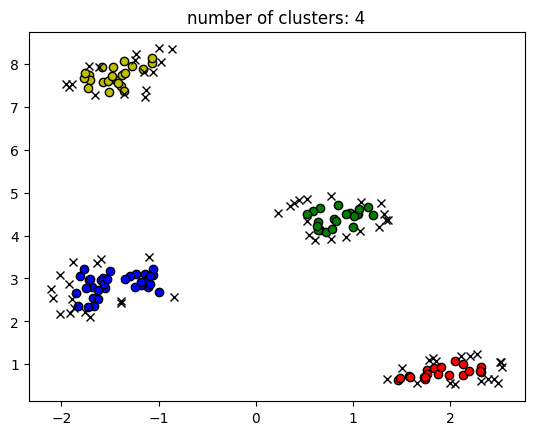

In [4]:
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:
       
        col = 'k'

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'x', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

#### Evaluation Metrics

We will use the `Silhouette score` and `Adjusted rand score` for evaluating clustering algorithms.

- `Silhouette's score` is in the range of -1 to 1. A score near 1 denotes the best meaning that the data point `i` is very compact within the cluster to which it belongs and far away from the other clusters. The worst value is -1. Values near 0 denote overlapping clusters.
- `Adjusted Rand Score` is in the range of 0 to 1. More than 0.9 denotes excellent cluster recovery and above 0.8 is a good recovery. Less than 0.5 is considered to be poor recovery. 

In [5]:
from sklearn import metrics
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = metrics.adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.13
Adjusted Rand Index: 0.31
